# Fréchet Means for Alpha Connections

The exponential barycenter is the affine-connection analogue of the Fréchet mean:

$$\frac{1}{N} \sum_{i=1}^N \log_{\bar{x}}^{(\alpha)}(x_i) = 0$$

where $\log^{(\alpha)}$ is the logarithm of the $\alpha$-connection.

Gradient descent on this functional gives:

$$\bar{x}_{t+1} = \exp_{\bar{x}_t}^{(\alpha)}\!\left(\eta \cdot \frac{1}{N}\sum_i \log_{\bar{x}_t}^{(\alpha)}(x_i)\right)$$

For $\alpha = 0$ (Fisher-Rao connection), the exponential barycenter should match the Riemannian Fréchet mean.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

import geomstats.backend as gs
import geomstats.visualization as visualization
from geomstats.information_geometry.normal import (
    UnivariateNormalAlpha,
    UnivariateNormalDistributions,
)
from geomstats.learning.exponential_barycenter import GeneralExponentialBarycenter
from geomstats.learning.frechet_mean import FrechetMean
from scipy.stats import norm

# Simulation Setup

## Define the Alpha Space

In [2]:
def create_alpha_space(alpha, riemannian_manifold):
    space = UnivariateNormalDistributions(equip=False)
    space.equip_with_connection(
        UnivariateNormalAlpha,
        riemannian_manifold=riemannian_manifold,
        alpha=alpha,
    )
    return space

## Analytic Cases for $\alpha=-1$ and $\alpha=1$

We define here two algorithms for computing barycenters in the extreme cases $\alpha = 1$ and $\alpha = -1$, in order to compare the analytical and numerical results. The purpose is to validate the correctness of the estimates produced by the general iterative solver.

In [3]:
def mixture_barycenter(points):
    mu_bar = 0
    for i in range(len(points)):
        mu_bar += points[i][0]
    mu_bar /= len(points)
    sigma_bar = sum(pt[1] ** 2 + (pt[0] - mu_bar) ** 2 for pt in points)
    sigma_bar /= len(points)
    sigma_bar = np.sqrt(sigma_bar)
    return mu_bar, sigma_bar

def exponential_barycenter(points):
    denominator = 0
    sigma_bar = 0
    for i in range(len(points)):
        denominator += 1 / points[i][1] ** 2
    sigma_bar = np.sqrt(len(points) / denominator)
    mu_bar = 0
    for i in range(len(points)):
        mu_bar += points[i][0] / points[i][1] ** 2
    mu_bar /= denominator
    return mu_bar, sigma_bar

## Alpha Barycenters and the Fréchet Mean

In [4]:
alphas = [-1.0, -0.5, 0.0, 0.5, 1.0]
riemannian_manifold = UnivariateNormalDistributions(equip=True)

def compute_barycenters(points, alphas, riemannian_manifold):
    means = {}
    for alpha in alphas:
        space = create_alpha_space(alpha, riemannian_manifold)
        estimator = GeneralExponentialBarycenter(space)
        estimator.fit(points)
        means[alpha] = estimator.estimate_

    frechet = FrechetMean(riemannian_manifold)
    frechet.fit(points)
    riemannian_mean = frechet.estimate_
    return means, riemannian_mean

## Poincaré Half-Plane View

We define here a visualization function for displaying the $\alpha$-barycenters in the parameter space.

In [ ]:
def plot_barycenters(alphas, points, means, riemannian_mean, points_added = None):
    colors = plt.cm.viridis(np.linspace(0, 1, len(alphas)))
    alpha_styles = {
        alpha: (colors[i], rf"$\alpha$={alpha:.4f}")
        for i, alpha in enumerate(alphas)
    }
    fig, ax = plt.subplots(figsize=(15, 7))
    visualization.plot(
        points,
        ax=ax,
        space="H2_poincare_half_plane",
        coords_type="half-space",
        marker="o",
        color="black",
        s=10,
        alpha=0.6,
        label="Data points",
    )

    if points_added is not None:
        visualization.plot(
            points_added,
            ax=ax,
            space="H2_poincare_half_plane",
            coords_type="half-space",
            marker="o",
            color="red",
            s=10,
            alpha=0.6,
            label="Added data points",
        )

    for alpha, (color, label) in alpha_styles.items():
        visualization.plot(
            means[alpha][None],
            ax=ax,
            space="H2_poincare_half_plane",
            coords_type="half-space",
            marker="x",
            color=color,
            s=100,
            label=label,
        )
    visualization.plot(
        riemannian_mean[None],
        ax=ax,
        space="H2_poincare_half_plane",
        coords_type="half-space",
        marker="o",
        color="green",
        s=250,
        label="Riemannian Fréchet mean",
        alpha=0.3,
    )


    if points_added is not None:
        points = gs.concatenate([points, points_added])
    mu_mix, sigma_mix = mixture_barycenter(points)
    mu_exp, sigma_exp = exponential_barycenter(points)
    ax.plot(
        mu_mix,
        sigma_mix,
        marker="+",
        color="black",
        markersize=10,
        label="Mixture barycenter",
    )
    ax.plot(
        mu_exp,
        sigma_exp,
        marker="+",
        color="black",
        markersize=10,
        label="Exponential barycenter",
    )

    ax.set_title(
        "$\\alpha$-barycenters for different values of $\\alpha$ (parameter space)",
        fontsize=16,
    )
    ax.set_xlabel("$\\mu$")
    ax.set_ylabel("$\\sigma$")
    ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)

    plt.tight_layout()
    plt.show()

## Parameter Evolution with Alpha

We define here a function for plotting the evolution of each barycenter parameter as a function of $\alpha$.

In [6]:
def set_min_yspan(ax, epsilon):
    ymin, ymax = ax.get_ylim()
    mid = (ymin + ymax) / 2
    if ymax - ymin < epsilon:
        ax.set_ylim(mid - epsilon / 2, mid + epsilon / 2)

def plot_alpha_parameter_evolution(alphas, means, epsilon = 0.1):
    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    ax1.plot(
        alphas,
        [means[alpha][0] for alpha in alphas],
        "o",
        linestyle="--",
        markersize=4,
        linewidth=1.5,
        color="grey",
    )
    ax1.grid(True)

    ax1.set_xlabel(r"$\alpha$")
    ax1.set_ylabel("Barycenter mean")
    ax1.set_title(r"Barycenter mean vs $\alpha$")

    set_min_yspan(ax1, epsilon)

    ax2.plot(
        alphas,
        [means[alpha][1] for alpha in alphas],
        "o",
        linestyle="--",
        markersize=4,
        linewidth=1.5,
        color="grey",
    )
    ax2.grid(True)

    set_min_yspan(ax2, epsilon)

    ax2.set_xlabel(r"$\alpha$")
    ax2.set_ylabel("Barycenter variance")
    ax2.set_title(r"Barycenter variance vs $\alpha$")

    plt.suptitle(
        r"Evolution of the $\alpha$-barycenter parameters with respect to $\alpha$",
        fontsize=16,
    )
    plt.tight_layout()
    plt.show()

## Density Comparisons

We define here a function for visualizing the probability densities of the data points together with those of their corresponding $\alpha$-barycenters.

In [7]:
def plot_densities(points, means, alphas, riemannian_mean, x_min, x_max):
    x = np.linspace(x_min, x_max, 300)

    fig, ax = plt.subplots(figsize=(10, 5))
    for mu, sigma in points:
        ax.plot(
            x,
            norm.pdf(x, mu, sigma),
            linestyle="--",
            linewidth=0.5,
            color="gray",
        )

    mu, sigma = points[0]
    ax.plot(
        x,
        norm.pdf(x, mu, sigma),
        linestyle="--",
        linewidth=0.5,
        color="gray",
        label="Data densities",
    )

    colors = plt.cm.viridis(np.linspace(0, 1, len(means)))
    for i in range(len(means)):
        mu, sigma = means[alphas[i]]
        ax.plot(
            x,
            norm.pdf(x, mu, sigma),
            color=colors[i],
            label=rf"$\alpha$={alphas[i]}",
        )

    x = np.linspace(x_min, x_max, 30)
    mu, sigma = riemannian_mean
    ax.plot(
        x,
        norm.pdf(x, loc=mu, scale=sigma),
        color="black",
        marker="o",
        markersize=2,
        linestyle="none",
        label="Riemannian Fréchet mean",
    )

    ax.set_xlim(x_min, x_max)
    ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
    ax.set_title("$\\alpha$-barycenter for different values of $\\alpha$ (densities)", fontsize=16)
    plt.tight_layout()
    plt.show()

# Simulations

### Default Settings

In [8]:
riemannian_manifold = UnivariateNormalDistributions(equip=True)
alphas = np.linspace(-1.0, 1.0, 21)
alphas_reduced = [-1.0, -0.5, 0.0, 0.5, 1.0]
alphas_test =[0.0]

## Random Points in the Poincaré Half-Plane

### Sample Generation

In [9]:
n_points = 20
mus = [random.uniform(-5,5) for _ in range(n_points)]
sigmas = [random.uniform(0.5,5.0) for _ in range(n_points)]

random_points = gs.array(np.stack([mus, sigmas], axis=-1))

print([(float(random_points[i][0]),float(random_points[i][1])) for i in range(len(random_points))])

[(-3.962050081259311, 2.773955744388278), (3.3485445911676806, 2.83006325439308), (-1.4731104652678626, 4.935676132284315), (1.344966082301175, 1.6149731679133759), (1.8444350176514224, 3.0919739370976527), (3.1060765253938563, 2.6266889924084724), (1.1135586012610998, 2.5232069505153802), (2.152483005178042, 3.2118060889639923), (-0.7592811379543463, 4.564745536694274), (-4.812382181708072, 4.023059025542915), (-3.9193355279344644, 2.515626416763541), (1.7302723438177718, 1.217111515655157), (2.702531955986734, 4.9718819258323075), (-4.997526894291534, 0.9101831823483617), (1.209919105743074, 0.5239880877271642), (2.1302573830863096, 1.0047158172806523), (-3.6491707005215313, 4.439396082421452), (-2.3743957617679854, 1.914470556986345), (0.539174624968477, 1.495333518044362), (2.977669068099016, 3.355284287904564)]


### Plotting

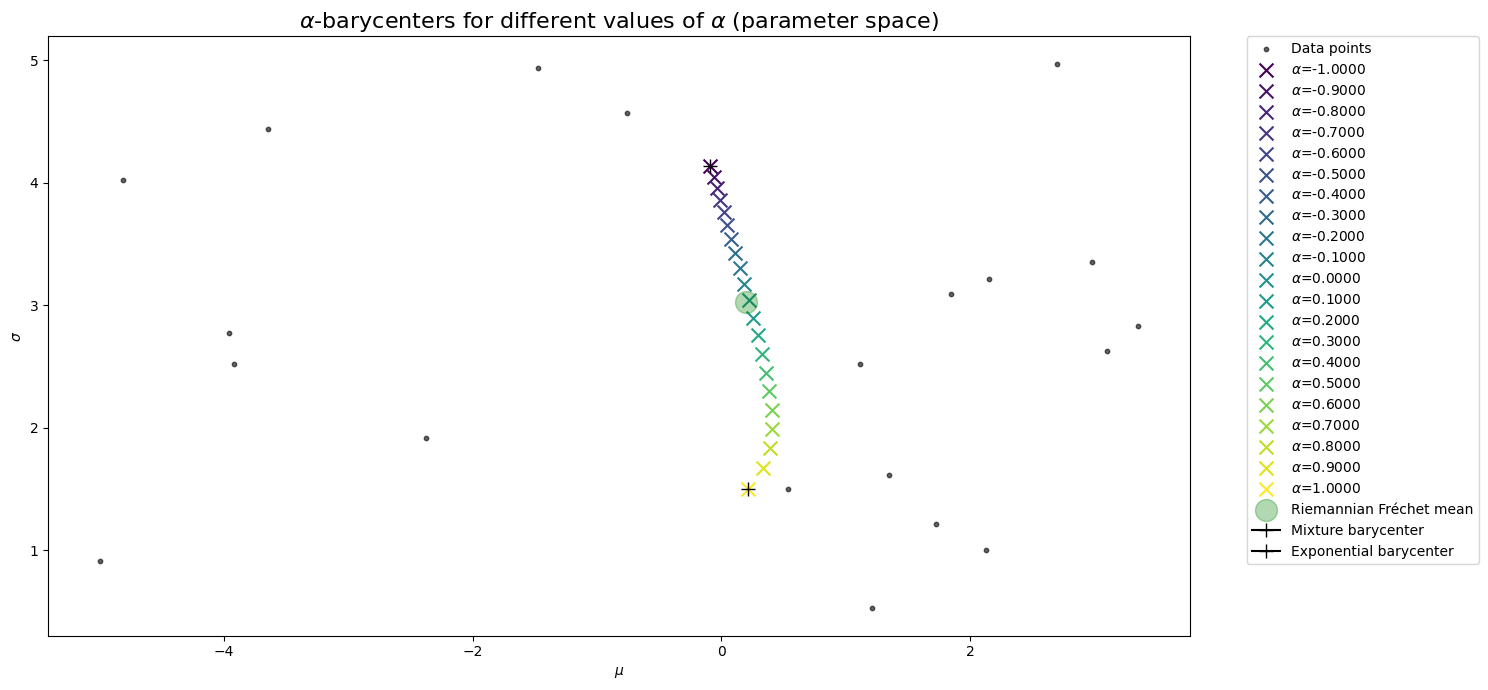

In [10]:
means_random, riemannian_mean_random = compute_barycenters(random_points, alphas, riemannian_manifold)
plot_barycenters(alphas, random_points, means_random, riemannian_mean_random)

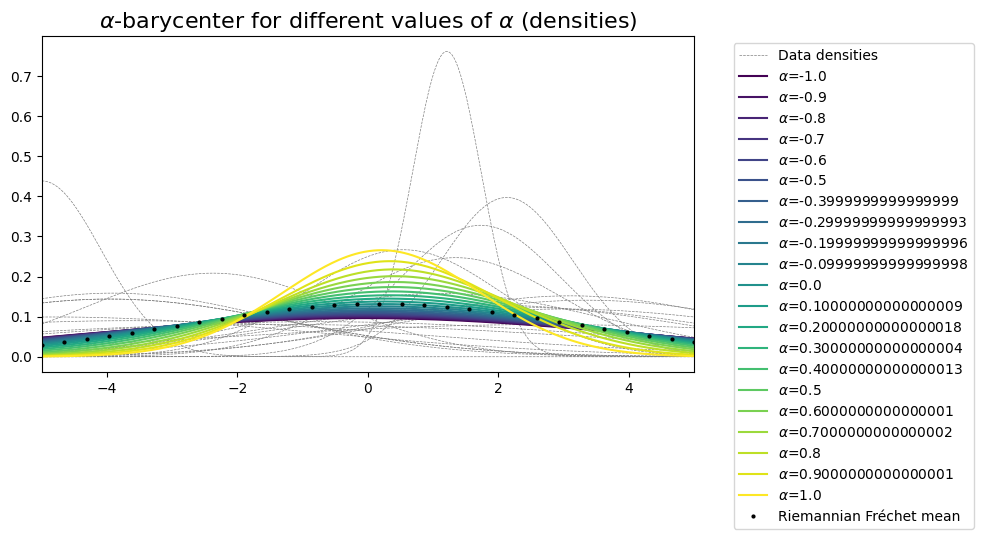

In [11]:
plot_densities(random_points, means_random, alphas, riemannian_mean_random, x_min=-5.0, x_max=5.0)

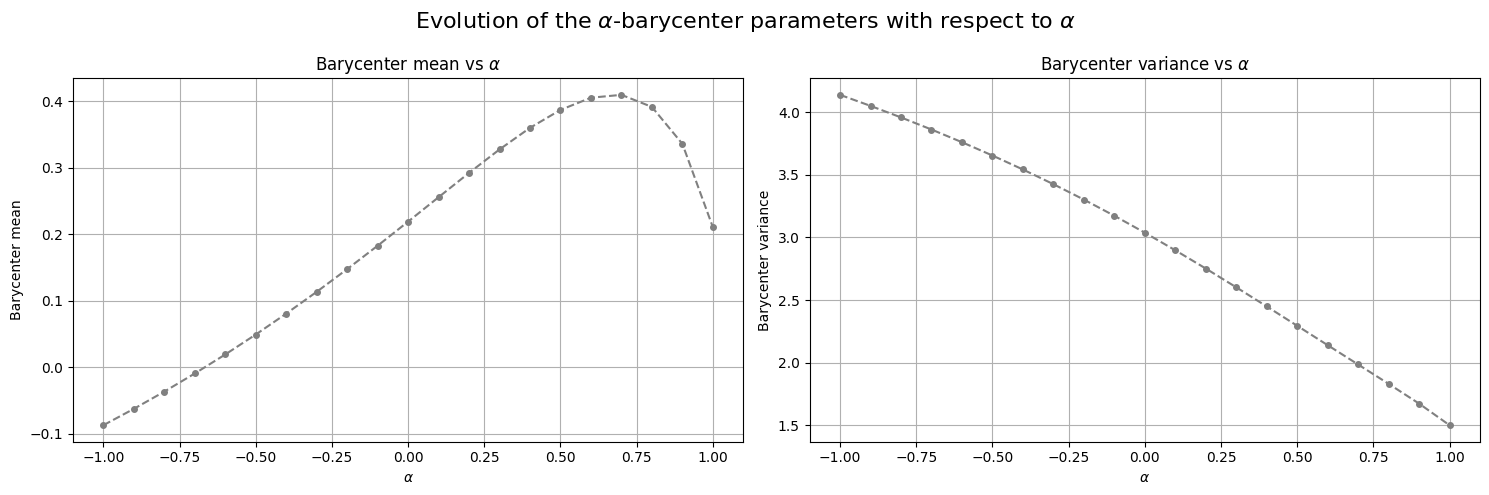

In [12]:
plot_alpha_parameter_evolution(alphas, means_random)

## Sphere Comparisons

### Sample Generation

In [13]:
def generate_symmetric_sphere_points(n_points, seed=0):
    """Generate evenly spaced points on the circle centered at (0, 2)."""
    theta = gs.linspace(0, 2 * gs.pi, n_points, endpoint=False)
    center = gs.array([0.0, 2.0])

    pts = gs.stack(
        [
            center[0] + gs.cos(theta),
            center[1] + gs.sin(theta),
        ],
        axis=-1,
    )

    return gs.array(pts)

points_sphere = generate_symmetric_sphere_points(n_points=30, seed=42)

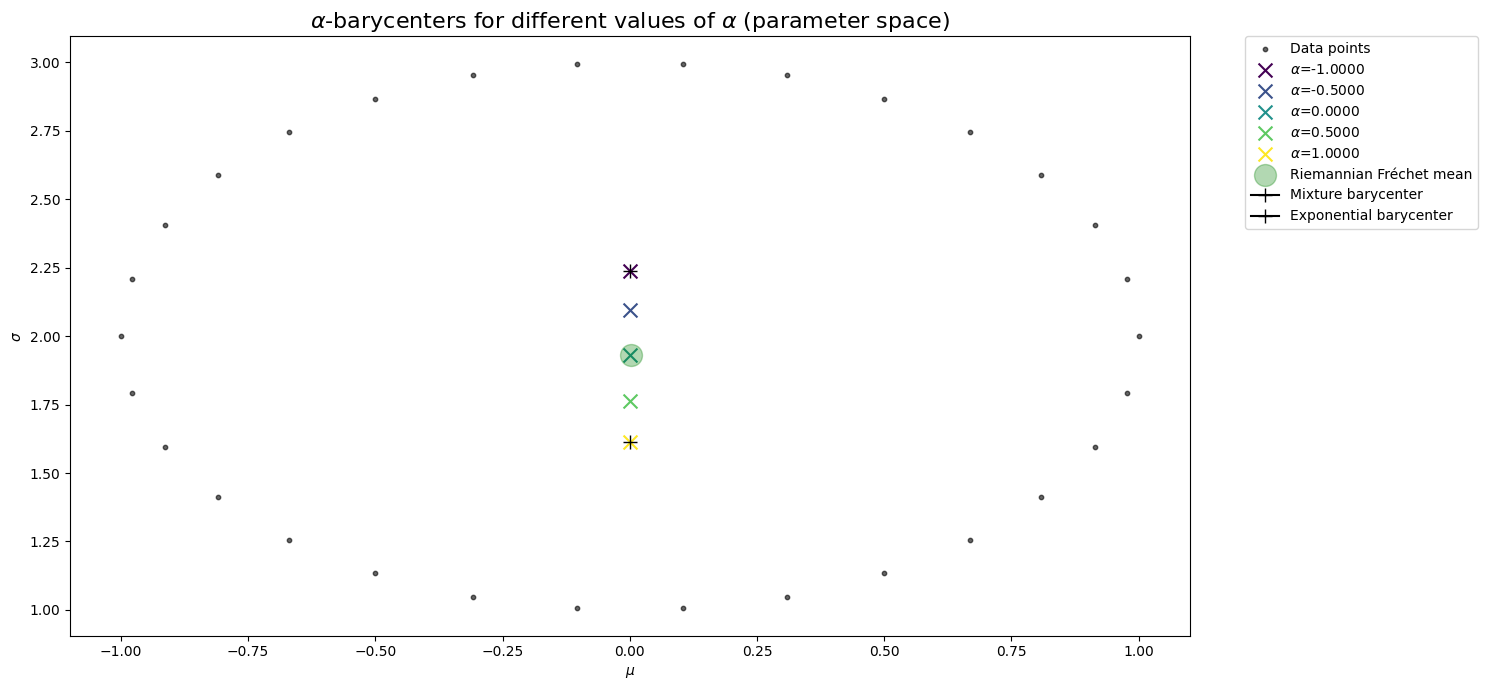

In [14]:
means_sphere, riemannian_mean_sphere = compute_barycenters(points_sphere, alphas_reduced, riemannian_manifold)
plot_barycenters(alphas_reduced, points_sphere, means_sphere, riemannian_mean_sphere)

The points are distributed symmetrically with respect to the axis $\{\mu = \mu_0\}$ for a fixed constant $\mu_0$. One can show that, provided the $\alpha$-barycenter exists and is unique, it necessarily lies on this axis of constant mean.

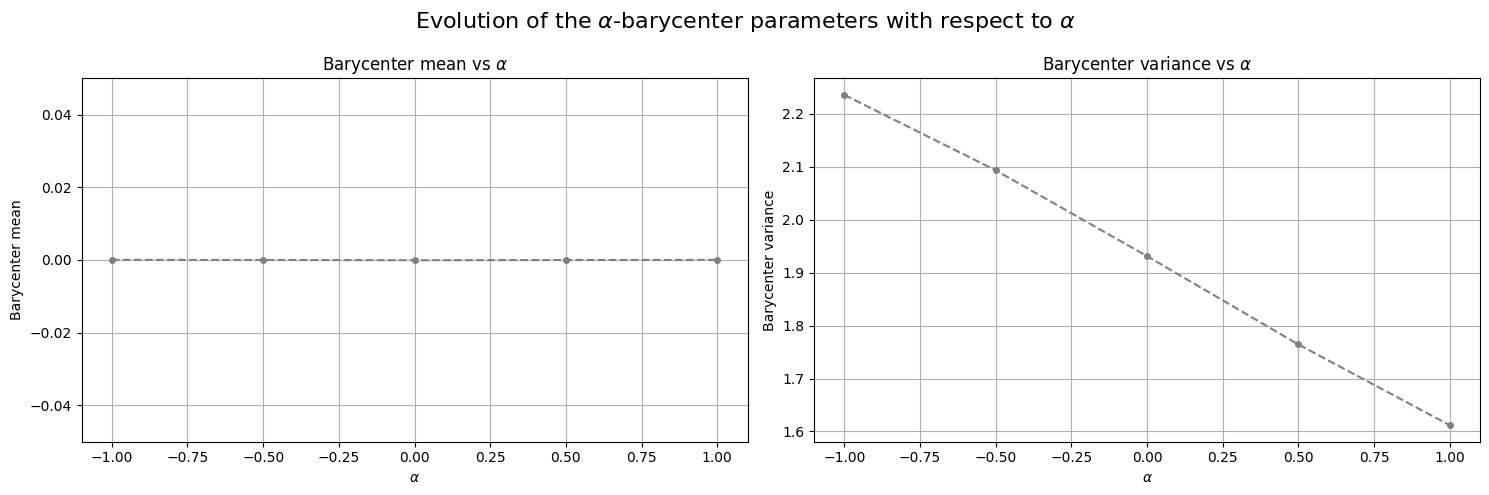

In [15]:
plot_alpha_parameter_evolution(alphas_reduced, means_sphere)

This plot confirms that the barycenter mean is constant across all values of $\alpha$, as expected from the symmetry argument. Moreover, the barycenter variance decreases monotonically as $\alpha$ increases — a pattern that recurs in all subsequent simulations, and which raises the question of whether this monotonicity can be established analytically. In certain special cases, such as distributions supported on a geodesic of constant mean, this behavior can indeed be proved.

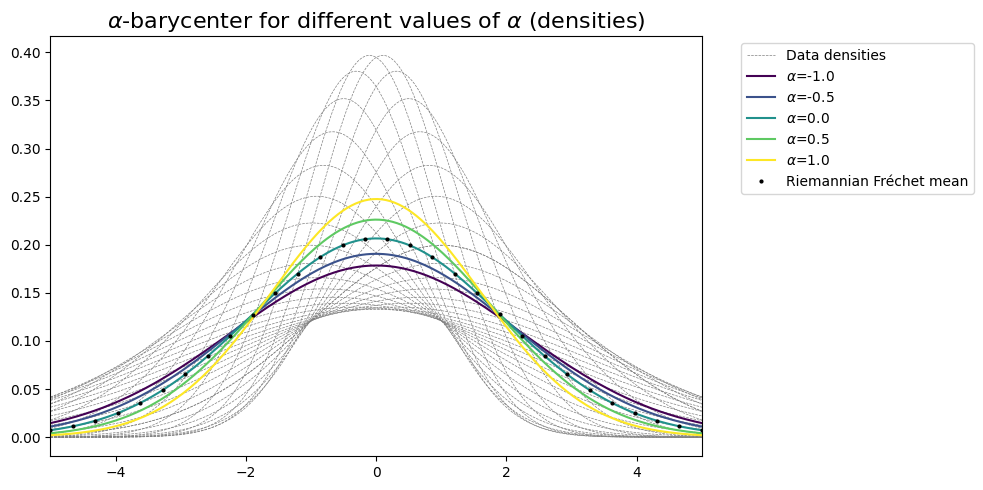

In [16]:
plot_densities(points_sphere, means_sphere, alphas_reduced, riemannian_mean_sphere, x_min=-5.0, x_max=5.0)

## Asymmetric Sphere Case

We now add some mass asymetrically, in order to break the symetry of the sphere

In order to break the symetry, we add a point in a random place on the sphere, just not in the line of constant mean. We chose to add this point P multiple times : if n is the number of points in the symetrical distribution of the sphere, then we add n times the point P. Here, P has an angle $\theta = \pi /10$

In [41]:
def generate_asymmetric_sphere_points(n_points, seed=0):
    """Generate evenly spaced points on the circle centered at (1, 2)."""
    theta = gs.linspace(0, 2 * gs.pi, n_points, endpoint=False)
    theta_trap = 0.1 * gs.pi
    theta_trap_bis = 0.1 * gs.pi + gs.pi
    center = gs.array([1.0, 2.0])

    pts = gs.stack(
        [
            center[0] + gs.cos(theta),
            center[1] + gs.sin(theta),
        ],
        axis=-1,
    )

    pt = [center[0] + gs.cos(theta_trap), center[1] + gs.sin(theta_trap)]
    pts_supp = gs.array([pt]*n_points)
    pts_concatenated = gs.concatenate([pts, pts_supp])

    return gs.array(pts_concatenated), gs.array(pts_supp), gs.array(pts)

points_sphere_asym, asym_part, sym_part = generate_asymmetric_sphere_points(n_points=30, seed=42)

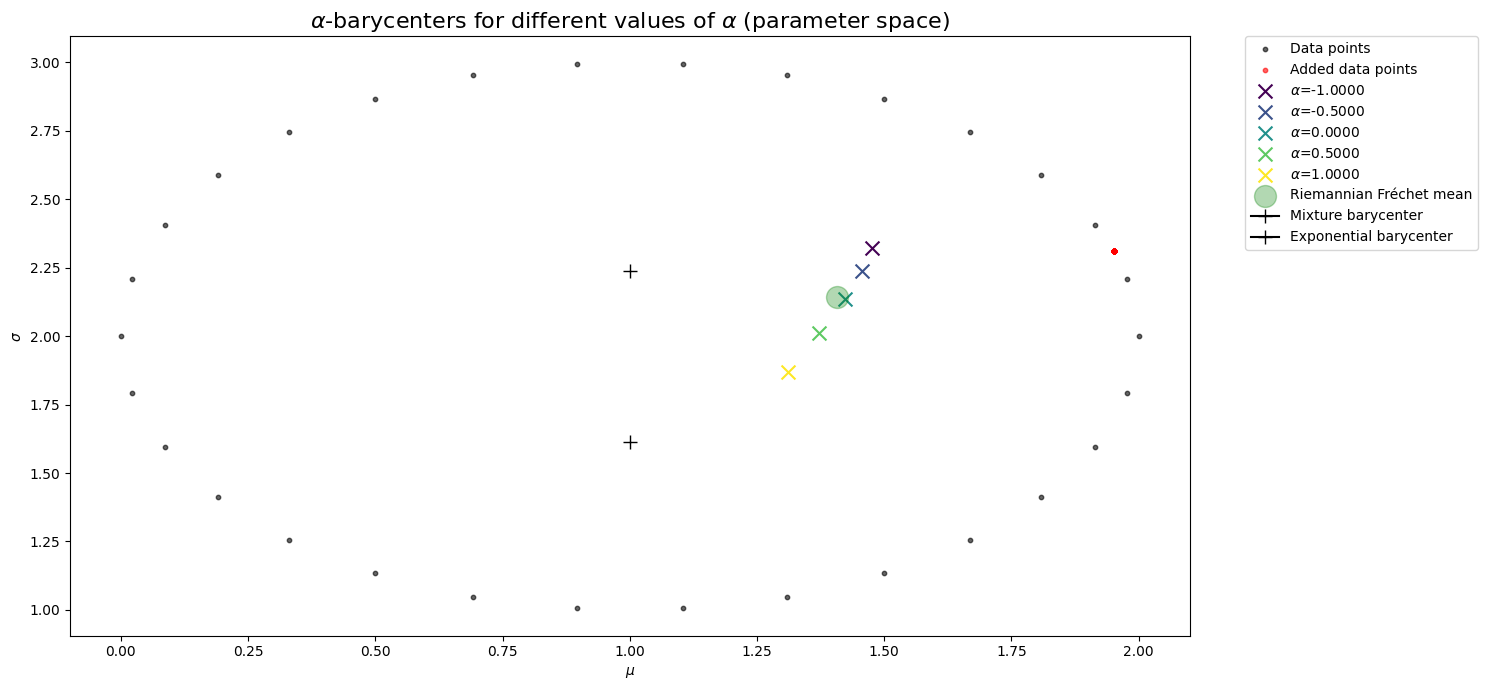

In [42]:
means_sphere_asym, riemannian_mean_sphere_asym = compute_barycenters(points_sphere_asym, alphas_reduced, riemannian_manifold)
plot_barycenters(alphas_reduced, sym_part, means_sphere_asym, riemannian_mean_sphere_asym, asym_part)

The $0$-barycenter and the Riemannian Fréchet mean do not coincide exactly in this experiment. This discrepancy is likely a numerical artifact due to the large number of points (90), which may affect the convergence of the iterative solver. By contrast, the $(-1)$-barycenter and the $1$-barycenter are validated against their closed-form expressions, confirming the correctness of the numerical scheme in these extreme cases.

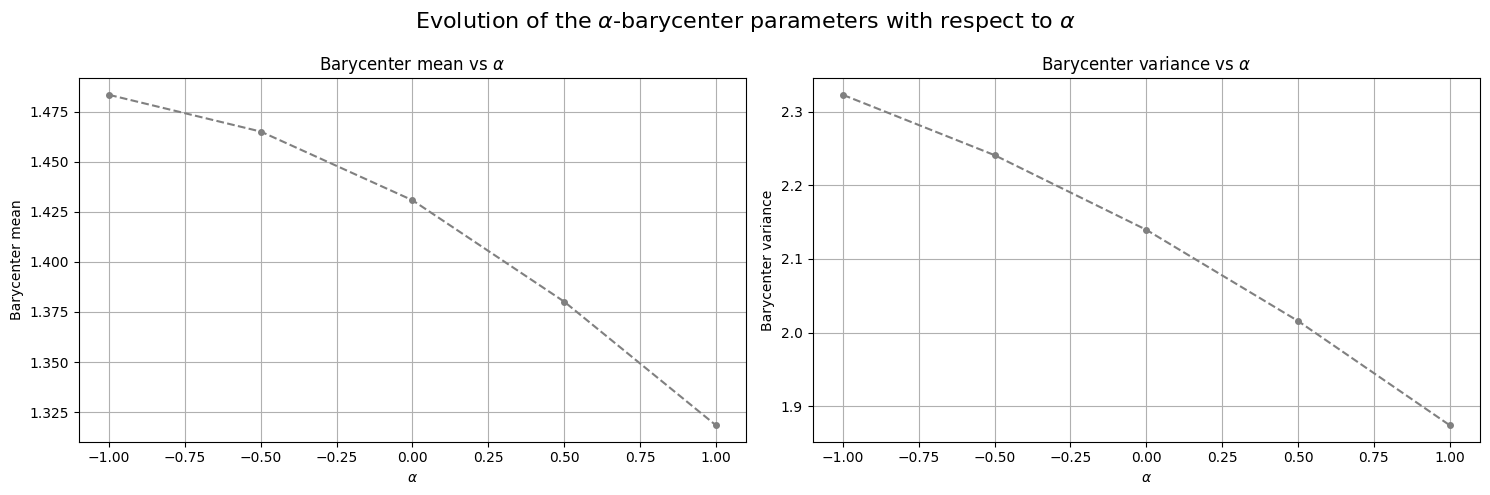

In [19]:
plot_alpha_parameter_evolution(alphas_reduced, means_sphere_asym)

By breaking the symmetry with respect to the axis of constant mean, we observe that the barycenter mean varies significantly across values of $\alpha$, demonstrating a strong dependence on $\alpha$. On the other hand, the monotone decrease of the variance with respect to $\alpha$ remains visible.

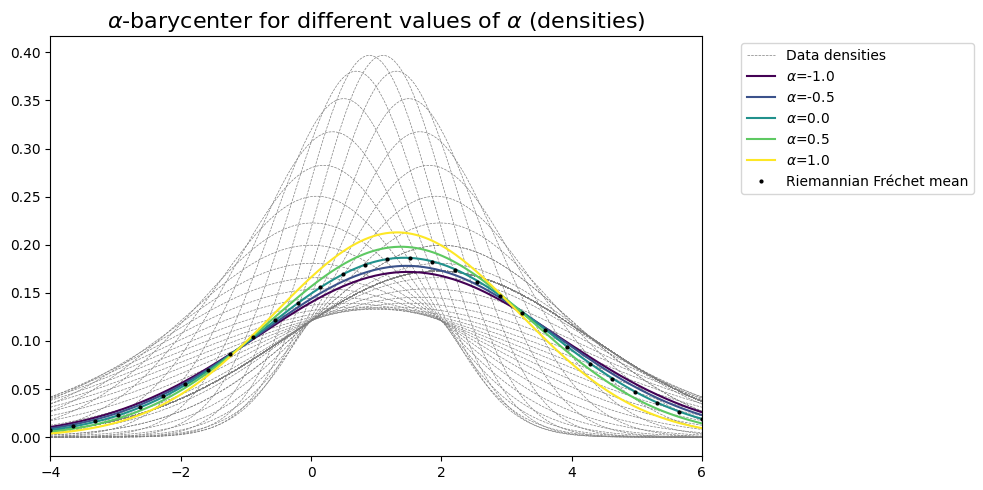

In [20]:
plot_densities(points_sphere_asym, means_sphere_asym, alphas_reduced, riemannian_mean_sphere_asym, x_min=-4.0, x_max=6.0)

abolition de la symétrie

## Other Examples

### Vertical and Horizontal Cases

In the following two examples, we recover the expected behavior of the barycenters: a constant mean across all values of $\alpha$, together with a monotonically decreasing variance as $\alpha$ increases.

In [21]:
mu_vals = np.linspace(-2, 2, 20)
sigma_val = 1.0
points_horizontal = np.array([[mu, sigma_val] for mu in mu_vals])
# Gaussians with the same scale and different means

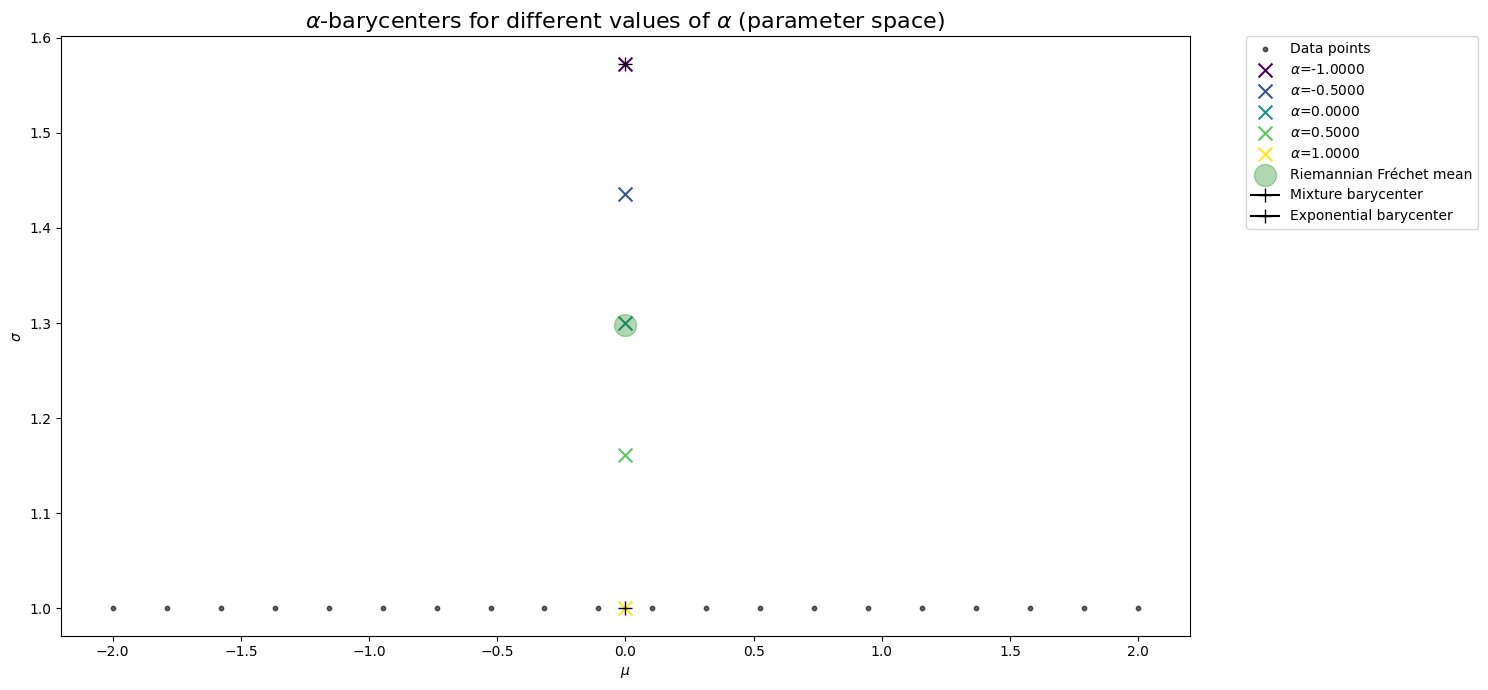

In [22]:
means_horizontal, riemannian_mean_horizontal = compute_barycenters(points_horizontal, alphas_reduced, riemannian_manifold)
plot_barycenters(alphas_reduced, points_horizontal, means_horizontal, riemannian_mean_horizontal)

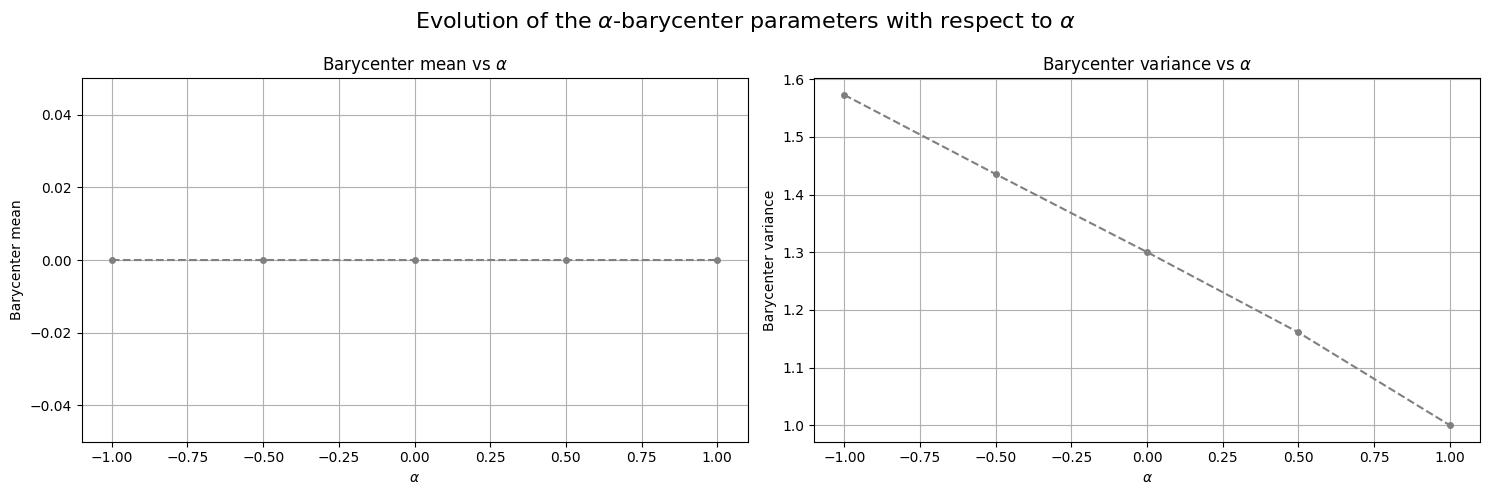

In [23]:
plot_alpha_parameter_evolution(alphas_reduced, means_horizontal)

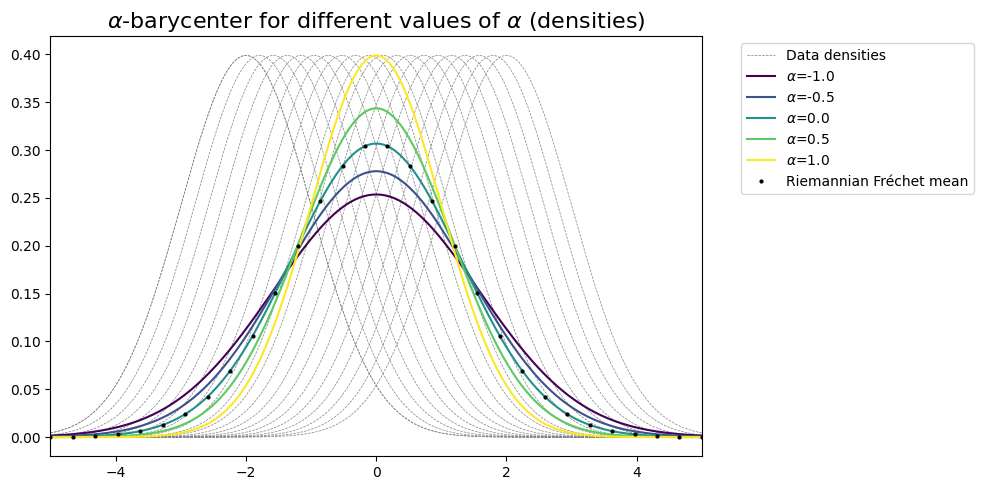

In [24]:
plot_densities(points_horizontal, means_horizontal, alphas_reduced, riemannian_mean_horizontal, x_min=-5.0, x_max=5.0)

In [25]:
mu_val = 0.0
sigma_vals = np.linspace(0.5, 2.5, 20)
points_vertical = np.array([[mu_val, sigma] for sigma in sigma_vals])
# Gaussians with the same mean and increasing scale

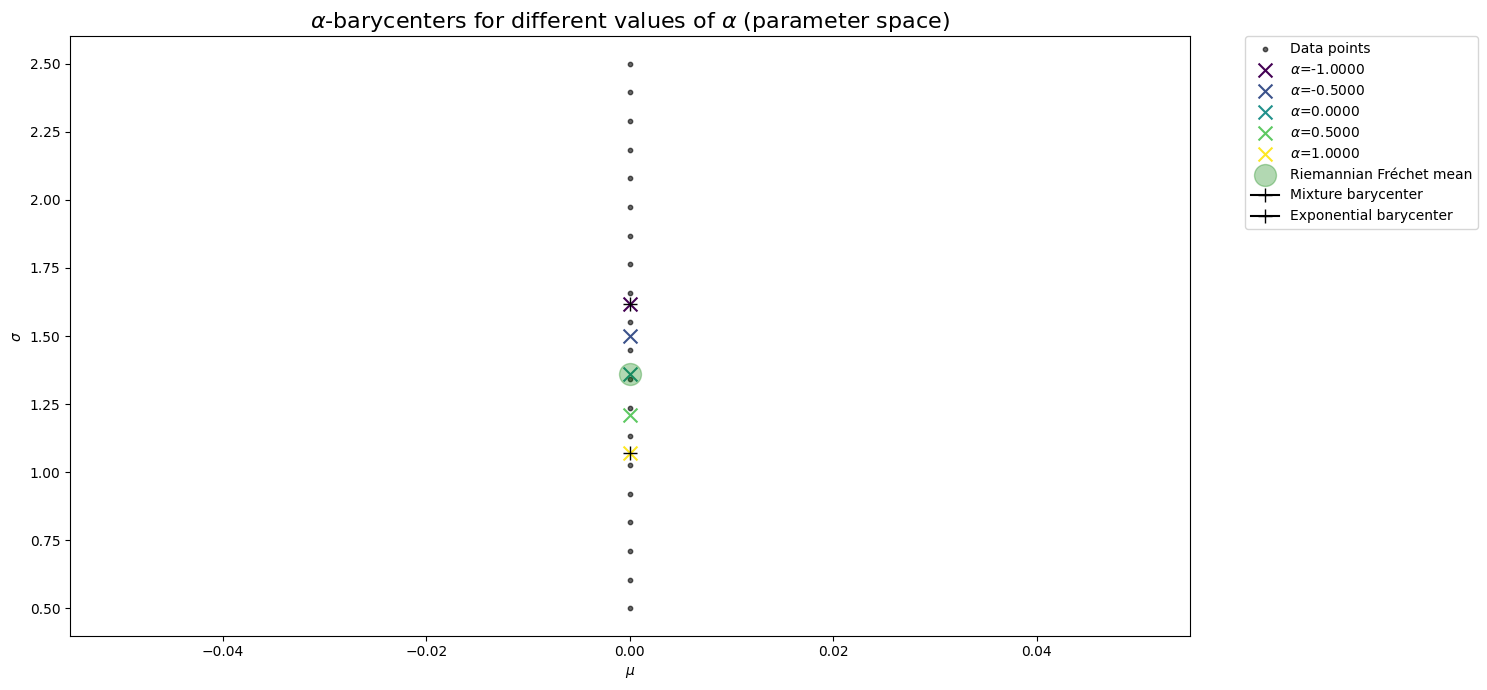

In [26]:
means_vertical, riemannian_mean_vertical = compute_barycenters(points_vertical, alphas_reduced, riemannian_manifold)
plot_barycenters(alphas_reduced, points_vertical, means_vertical, riemannian_mean_vertical)

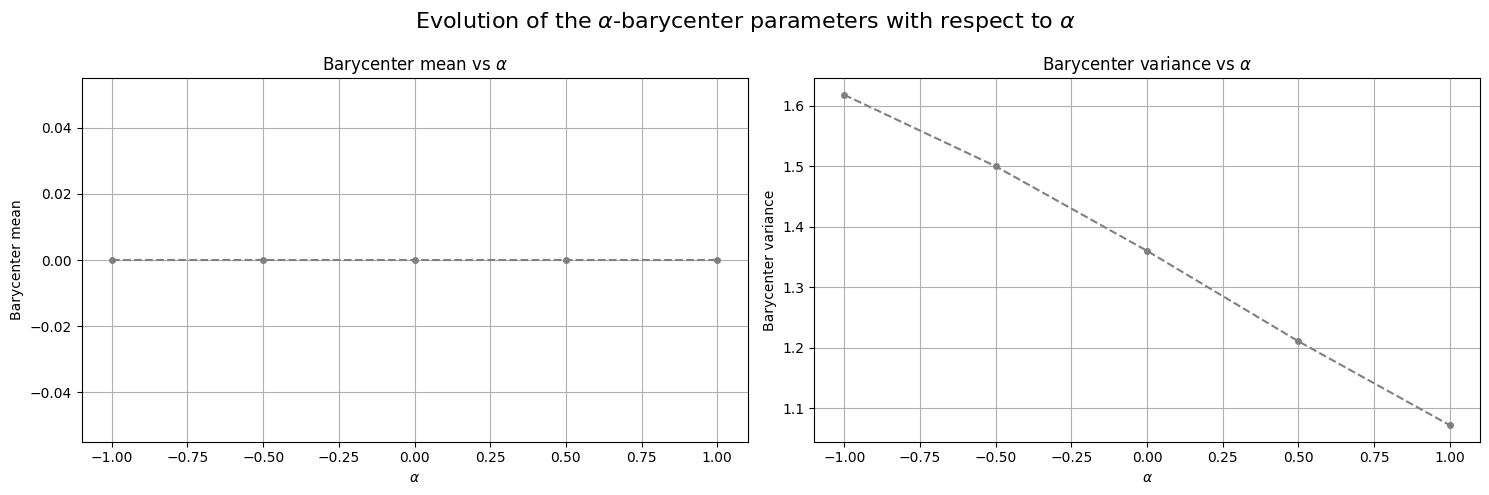

In [27]:
plot_alpha_parameter_evolution(alphas_reduced, means_vertical)

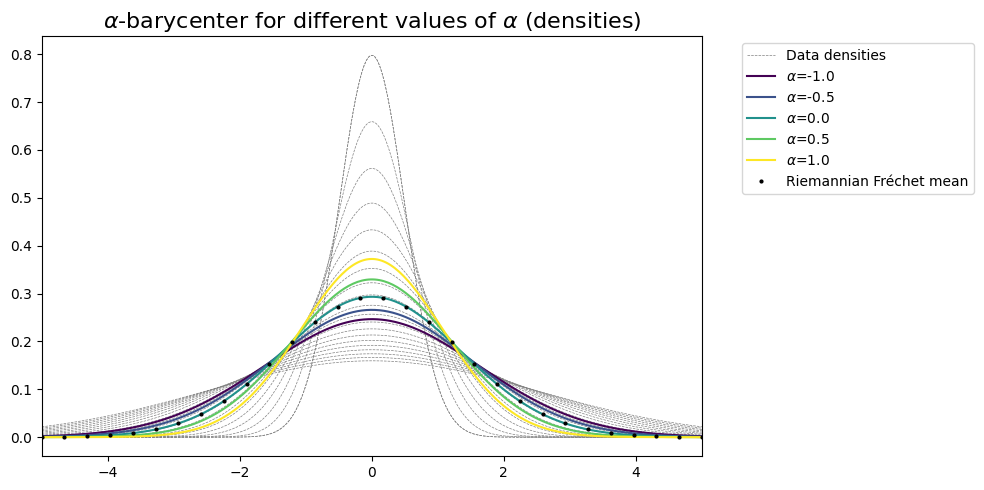

In [28]:
plot_densities(points_vertical, means_vertical, alphas_reduced, riemannian_mean_vertical, x_min=-5.0, x_max=5.0)

### Ellipse

In [29]:
t = np.linspace(0, 2 * np.pi, 20, endpoint=False)
a, b = 1.5, 0.8      # semi-axes
mu_center, sigma_center = 0.0, 1.5
points_ellipse = np.array([
    [mu_center + a * np.cos(ti), sigma_center + b * np.sin(ti)]
    for ti in t
])
# keep sigma positive, so sigma_center > b
# ellipse centered at (0, 1.5) with semi-axes a=1.5 and b=0.8



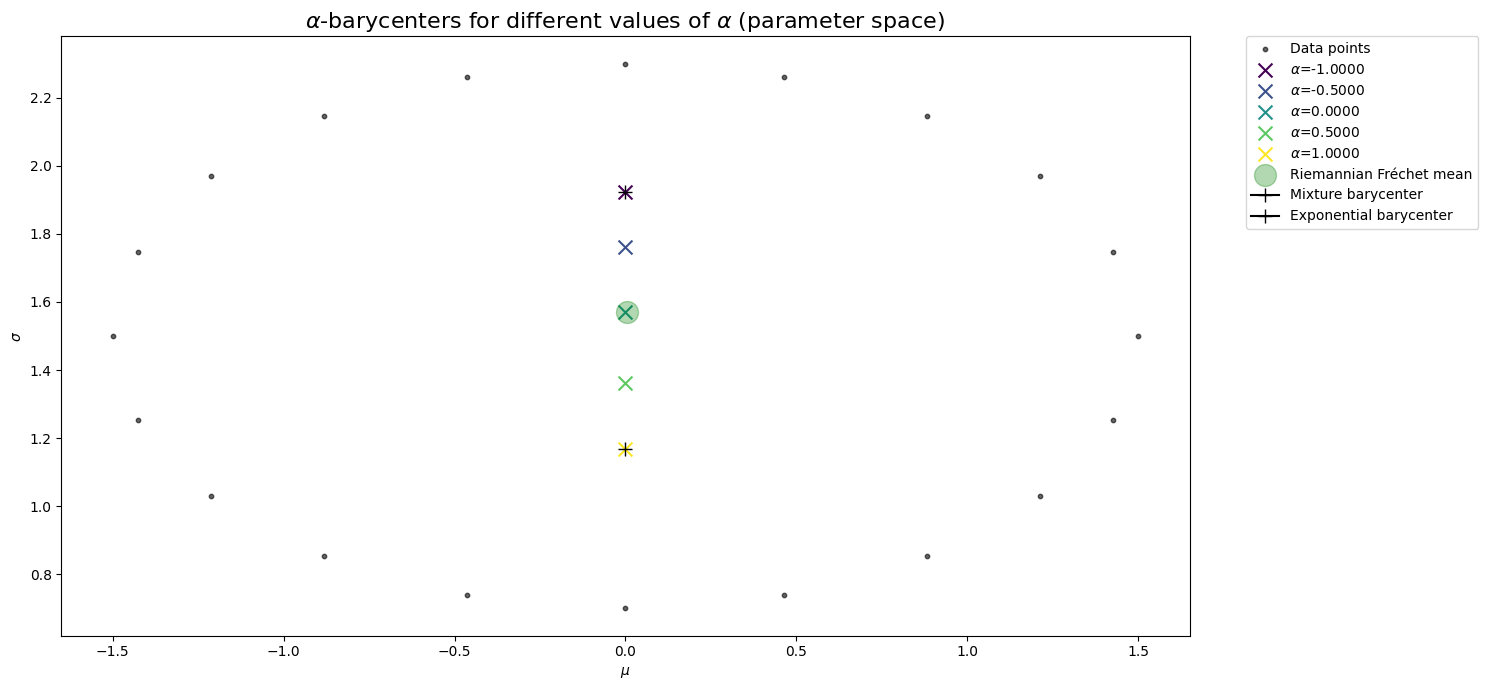

In [30]:
means_ellipse, riemannian_mean_ellipse = compute_barycenters(points_ellipse, alphas_reduced, riemannian_manifold)
plot_barycenters(alphas_reduced, points_ellipse, means_ellipse, riemannian_mean_ellipse)

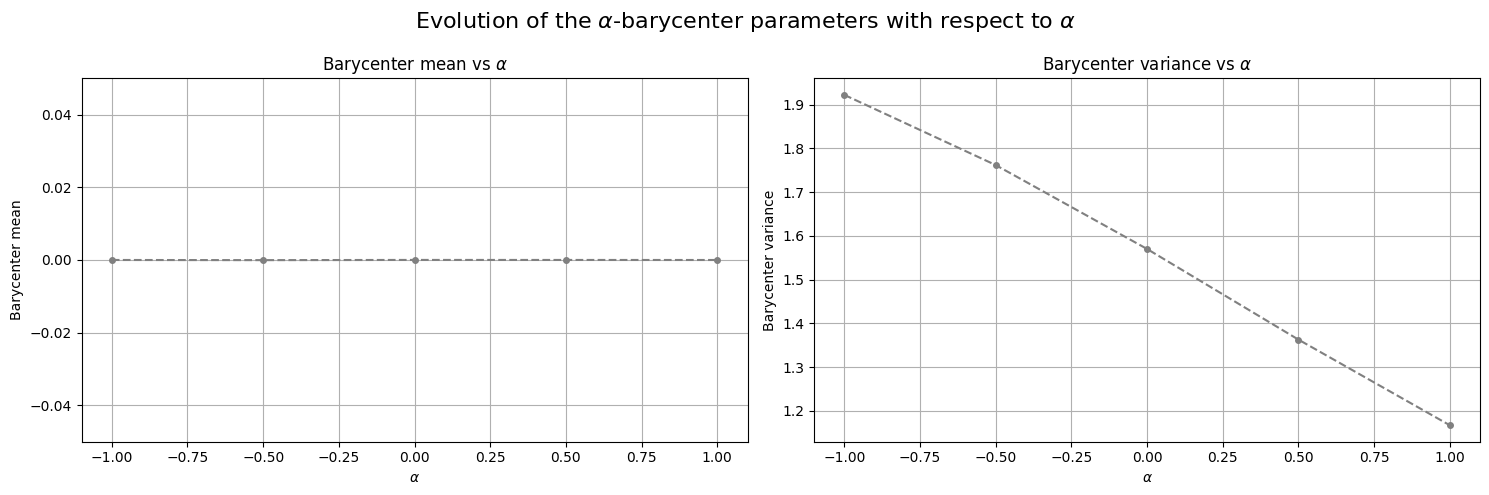

In [31]:
plot_alpha_parameter_evolution(alphas_reduced, means_ellipse)

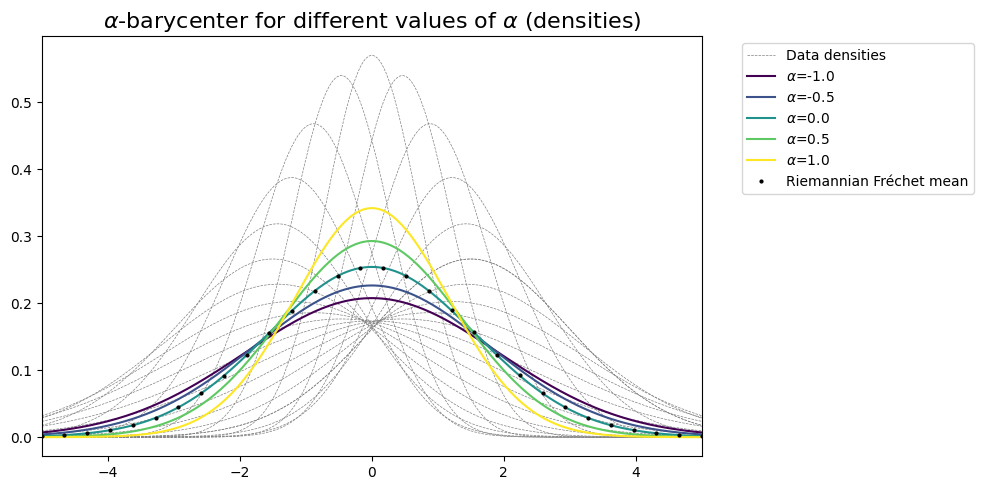

In [32]:
plot_densities(points_ellipse, means_ellipse, alphas_reduced, riemannian_mean_ellipse, x_min=-5.0, x_max=5.0)

### Diagonal

This choice of data distribution makes the contrast between the $\alpha = 1$ and $\alpha = -1$ barycenters most apparent, illustrating the $L^\infty$- and $L^1$-type behavior respectively.

We can already formulate a conjecture that appears consistent with the general theory of $\alpha$-connections. When $\alpha$ approaches $1$, the barycenter tends to concentrate near the zone where the global density is the highest - near the maximal mode, which suggests an analogy with an $L^\infty$-type criterion. Conversely, when $\alpha$ approaches $-1$, the barycenter tends to concentrate near the median of the modes, which looks more like an $L^1$-type criterion.

In the non-parametric setting, on the ambient space of all probability densities, it is precisely this projection onto the $L^p$ sphere — where $p$ depends on $\alpha$ — that defines the geometry of $\alpha$-connections. This interpretation appears to carry over naturally to the parametric submanifold setting considered here.

In [33]:
# Points on the diagonal mu = sigma
mu_vals = np.linspace(-2, 2, 20)
sigma_vals = np.linspace(0.5, 2.5, 20)
points_diag = np.array([[mu, sigma] for mu, sigma in zip(mu_vals, sigma_vals)])
# larger values to the right correspond to wider Gaussians


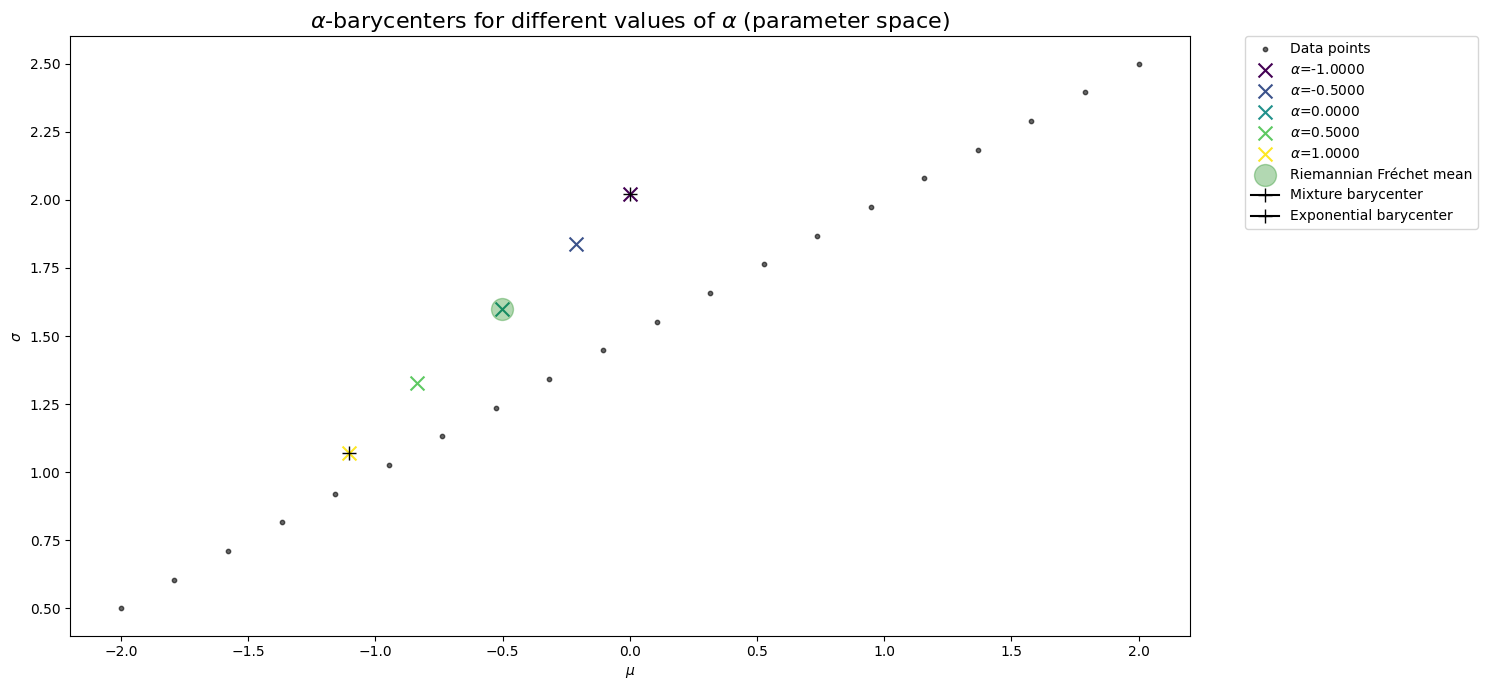

In [34]:
means_diag, riemannian_mean_diag = compute_barycenters(points_diag, alphas_reduced, riemannian_manifold)
plot_barycenters(alphas_reduced, points_diag, means_diag, riemannian_mean_diag)

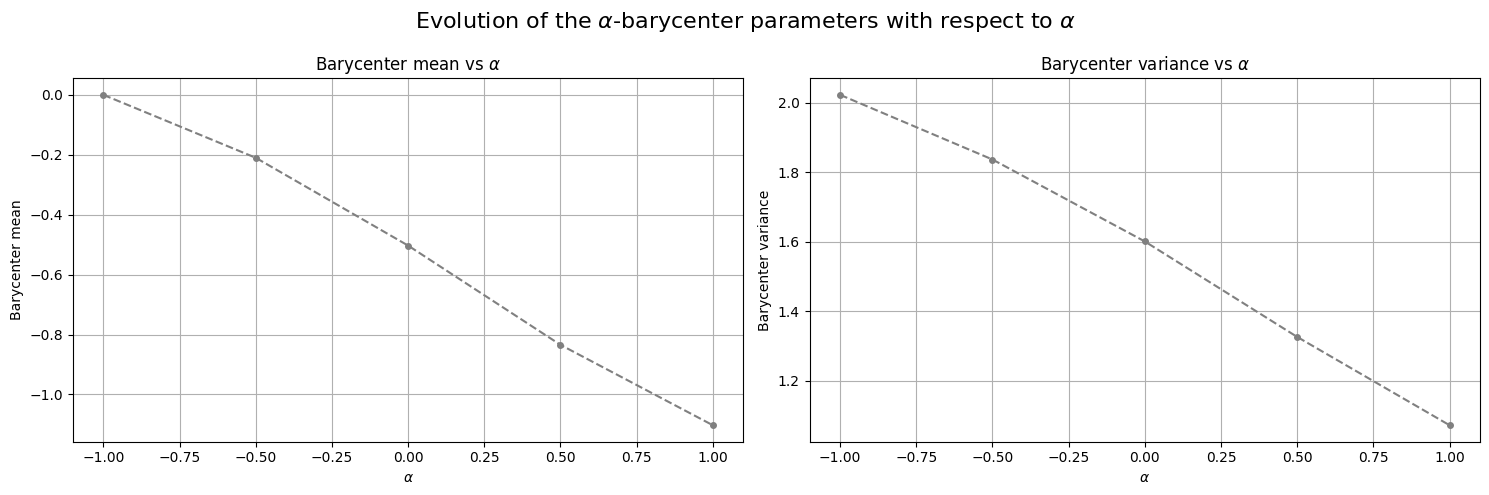

In [35]:
plot_alpha_parameter_evolution(alphas_reduced, means_diag)

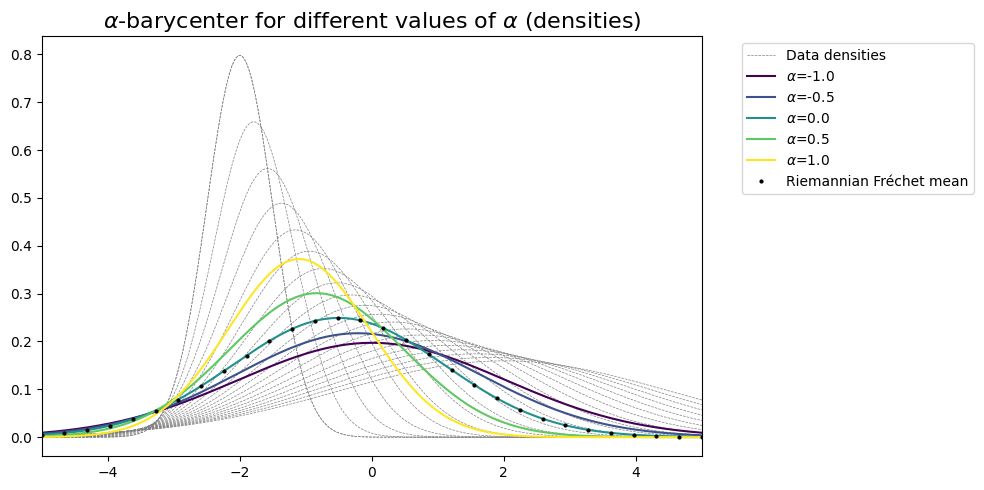

In [36]:
plot_densities(points_diag, means_diag, alphas_reduced, riemannian_mean_diag, x_min=-5.0, x_max=5.0)

### Grid

In [37]:
# Regular grid
mus = np.linspace(-1, 1, 3)
sigmas = np.linspace(0.5, 1.5, 3)
points_grid = np.array([[mu, sigma] for mu in mus for sigma in sigmas])


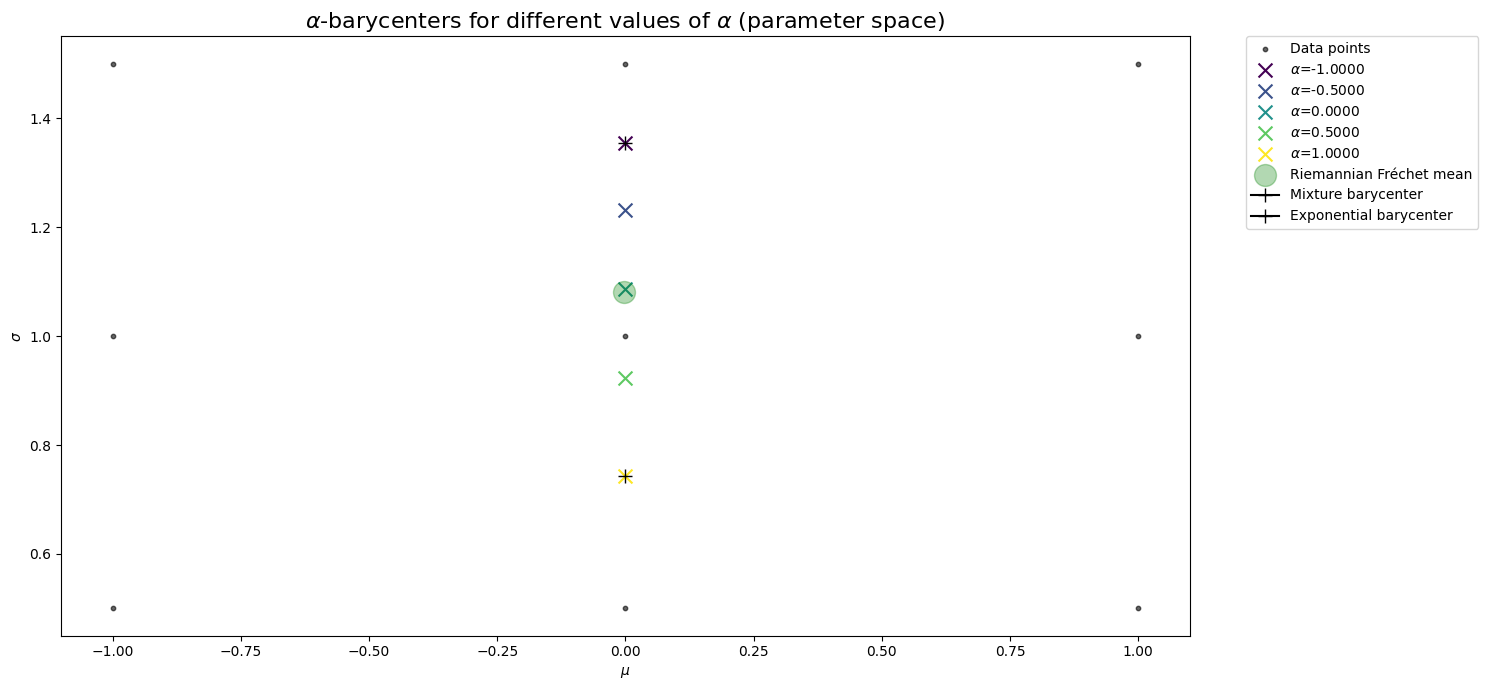

In [38]:
means_grid, riemannian_mean_grid = compute_barycenters(points_grid, alphas_reduced, riemannian_manifold)
plot_barycenters(alphas_reduced, points_grid, means_grid, riemannian_mean_grid)

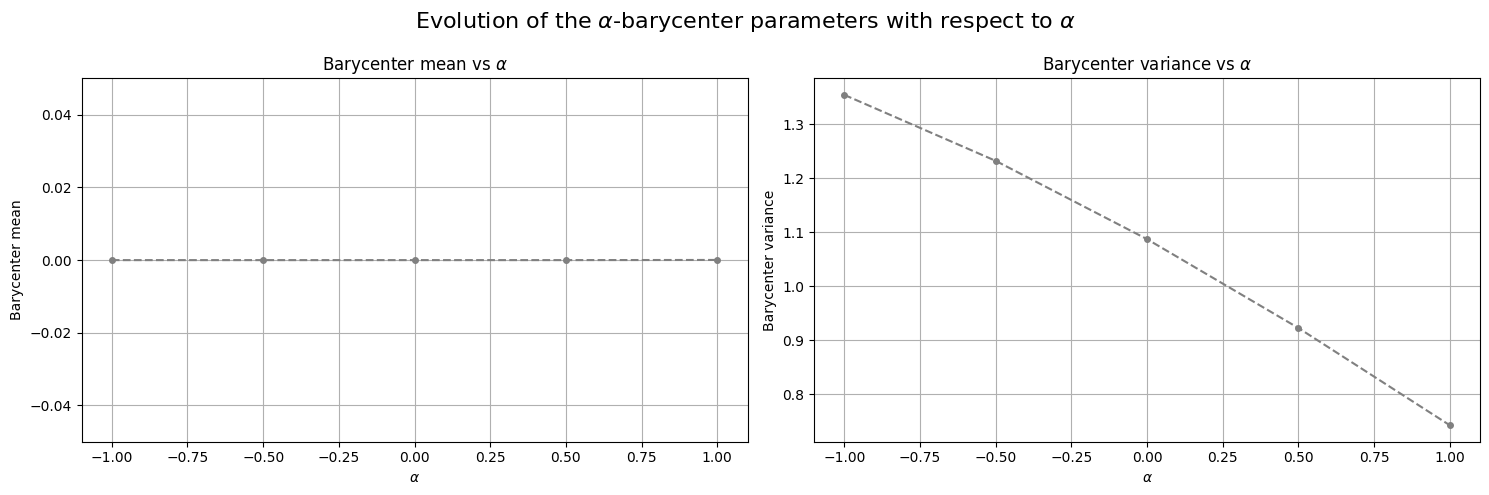

In [39]:
plot_alpha_parameter_evolution(alphas_reduced, means_grid)

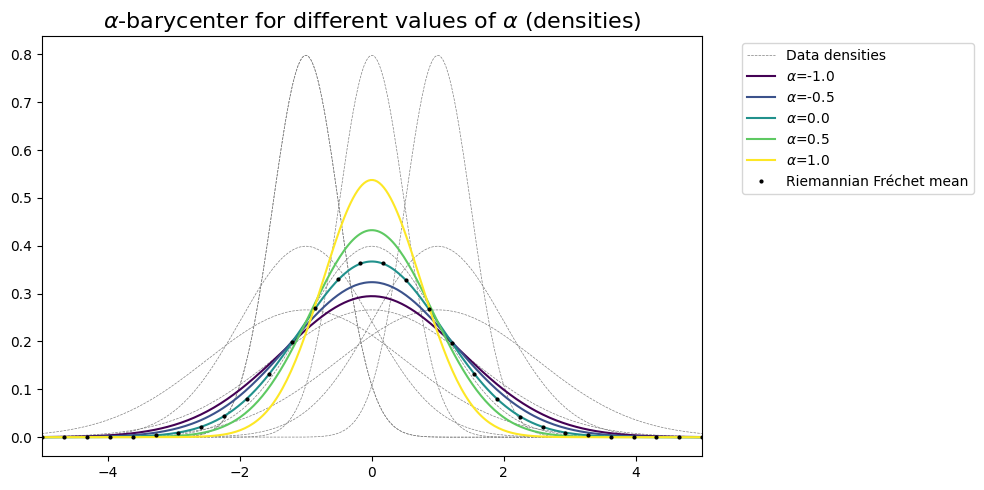

In [40]:
plot_densities(points_grid, means_grid, alphas_reduced, riemannian_mean_grid, x_min=-5.0, x_max=5.0)